In [12]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# 0 = all messages are logged (default behavior)
# 1 = INFO messages are not printed
# 2 = INFO and WARNING messages are not printed
# 3 = INFO, WARNING, and ERROR messages are not printed

import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler, MinMaxScaler
from keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
#from google.colab import drive
#drive.mount('/content/gdrive')

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

#import warnings
# https://stackoverflow.com/questions/15777951/how-to-suppress-pandas-future-warning
#warnings.simplefilter(action='ignore', category=FutureWarning)
#warnings.simplefilter(action='ignore', category=Warning)

tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

import logging
tf.get_logger().setLevel(logging.ERROR)

# https://stackoverflow.com/questions/65697623/tensorflow-warning-found-untraced-functions-such-as-lstm-cell-6-layer-call-and
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

In [ ]:
# gpu_info = !nvidia-smi
# gpu_info = '\n'.join(gpu_info)
# if gpu_info.find('failed') >= 0:
#   print('Not connected to a GPU')
# else:
#   print(gpu_info)

In [13]:
dfs = {}

df = pd.read_csv('/content/Station1_Revised_Final_Data.csv', sep=",", parse_dates=["Unnamed: 0"], index_col="Unnamed: 0")
dfs['Station1'] = df
# for index in range(0, 6):
#   df = pd.read_csv('Station' + str(index + 1) + '_simulated_cleaned_merged_data.csv', sep=",", parse_dates=["Unnamed: 0"], index_col="Unnamed: 0")
#   dfs['Station' + str(index + 1)] = df
#   df.index = pd.to_datetime(df.index)

print(df.isna().sum())


Ppt              0
SWC_5            0
SWC_10           0
SWC_20           0
SWC_50           0
T_5              0
T_10             0
T_20             0
T_50             0
Tair             0
RH               0
Windspeed        0
Winddirection    0
Srad             0
Latitude         0
Longitude        0
dtype: int64


In [14]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Ppt,52560.0,0.068205,8.405104e-01,-1.464373,0.0000,0.0000,0.0000,40.640000
SWC_5,52560.0,0.140254,5.154907e-02,0.004612,0.0950,0.1340,0.1830,0.309000
SWC_10,52560.0,0.157113,4.093361e-02,-0.023168,0.1230,0.1540,0.1920,0.298000
SWC_20,52560.0,0.137294,3.346671e-02,0.049357,0.1050,0.1360,0.1650,0.235000
SWC_50,52560.0,0.137377,3.578278e-02,0.076554,0.1030,0.1290,0.1700,0.249000
T_5,52560.0,22.992845,9.495459e+00,0.760000,15.5500,22.9300,30.0800,49.960000
T_10,52560.0,23.007369,8.874525e+00,2.000000,15.8000,23.1100,30.1700,44.440000
T_20,52560.0,22.948400,8.384273e+00,3.270000,15.9400,23.0800,30.0100,41.200000
T_50,52560.0,22.805075,7.007613e+00,7.880000,16.5200,22.5900,29.2300,35.400000
Tair,52560.0,14.142881,2.328434e+01,-173.200000,11.5775,19.3300,24.4200,172.476413


In [15]:
import numpy as np
import pandas as pd

def engineer_data(dfs, boolean):
    # Constants for day and year calculations
    day = 24 * 60 * 60
    year = 365.2425 * day

    for station, df in dfs.items():
        # Drop rows with NaN values to ensure clean data
        df = df.dropna()

        # Extract windspeed and wind direction
        wv = df['Windspeed']
        wd_rad = np.deg2rad(df['Winddirection'])  # Convert degrees to radians

        # Ensure the index is in datetime format
        df.index = pd.to_datetime(df.index)

        # Convert timestamp index to seconds
        timestamp_s = df.index.map(pd.Timestamp.timestamp)

        # Extract latitude and longitude
        lat = np.deg2rad(df['Latitude'])  # Convert latitude to radians
        lon = np.deg2rad(df['Longitude'])  # Convert longitude to radians

        # Engineer wind components

        # print("HELLO", wv * np.cos(wd_rad))
        # print("AHHHHH",wd_rad)

        if boolean:
          df['Wx'] = wv * np.cos(wd_rad)
          df['Wy'] = wv * np.sin(wd_rad)

        # Engineer time-based cyclic features
        df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
        df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
        df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
        df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

        # Engineer Cartesian coordinates for latitude and longitude
        df['x_cord'] = np.cos(lat) * np.cos(lon)
        df['y_cord'] = np.cos(lat) * np.sin(lon)
        df['z_cord'] = np.sin(lat)

        # Update the DataFrame in the dictionary
        dfs[station] = df

    return dfs





In [16]:
engineer_data(dfs, False)

engineer_data(dfs, True)



{'Station1':                      Ppt  SWC_5  SWC_10  SWC_20  SWC_50   T_5  T_10  T_20  \
 2015-01-01 00:00:00  0.0  0.139   0.178   0.148   0.152  2.81  4.40  5.77   
 2015-01-01 01:00:00  0.0  0.139   0.178   0.148   0.152  2.86  4.38  5.71   
 2015-01-01 02:00:00  0.0  0.139   0.178   0.148   0.152  2.89  4.35  5.66   
 2015-01-01 03:00:00  0.0  0.139   0.178   0.148   0.152  2.90  4.33  5.62   
 2015-01-01 04:00:00  0.0  0.139   0.178   0.148   0.152  2.96  4.32  5.59   
 ...                  ...    ...     ...     ...     ...   ...   ...   ...   
 2020-12-31 19:00:00  0.0  0.242   0.193   0.182   0.099  5.46  6.95  8.62   
 2020-12-31 20:00:00  0.0  0.236   0.191   0.182   0.099  5.43  6.80  8.40   
 2020-12-31 21:00:00  0.0  0.232   0.190   0.181   0.099  5.30  6.68  8.24   
 2020-12-31 22:00:00  0.0  0.229   0.189   0.181   0.099  5.29  6.55  8.09   
 2020-12-31 23:00:00  0.0  0.227   0.188   0.181   0.099  5.28  6.50  7.96   
 
                       T_50   Tair  ...  Longitude

In [22]:
dfs['Station1'].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Ppt,52560.0,3.639949e-02,1.996254e-02,0.000000,0.034780,3.477960e-02,0.034780,1.000000
SWC_5,52560.0,4.456228e-01,1.693529e-01,0.000000,0.296951,4.250767e-01,0.586055,1.000000
SWC_10,52560.0,5.613277e-01,1.274525e-01,0.000000,0.455113,5.516361e-01,0.669954,1.000000
SWC_20,52560.0,4.736859e-01,1.802750e-01,0.000000,0.299729,4.667170e-01,0.622931,1.000000
SWC_50,52560.0,3.527058e-01,2.075013e-01,0.000000,0.153359,3.041304e-01,0.541886,1.000000
T_5,52560.0,4.518871e-01,1.929971e-01,0.000000,0.300610,4.506098e-01,0.595935,1.000000
T_10,52560.0,4.949898e-01,2.091076e-01,0.000000,0.325165,4.974081e-01,0.663761,1.000000
T_20,52560.0,5.188083e-01,2.210460e-01,0.000000,0.334036,5.222779e-01,0.704983,1.000000
T_50,52560.0,5.423356e-01,2.546371e-01,0.000000,0.313953,5.345203e-01,0.775799,1.000000
Tair,52560.0,5.419603e-01,6.735878e-02,0.000000,0.534539,5.569660e-01,0.571691,1.000000


In [23]:
def scale_data(dfs):
    for station, df in dfs.items():
        cur_df = df.copy()
        d_sin = cur_df.pop("Day sin")
        d_cos = cur_df.pop("Day cos")
        y_sin = cur_df.pop("Year sin")
        y_cos = cur_df.pop("Year cos")
        x = cur_df.pop("x_cord")
        y = cur_df.pop("y_cord")
        z = cur_df.pop("z_cord")
        scaler = MinMaxScaler()
        scaled_df = pd.DataFrame(data=scaler.fit_transform(cur_df), columns=cur_df.columns, index=cur_df.index)
        scaled_df["Day sin"] = d_sin.values
        scaled_df["Day cos"] = d_cos.values
        scaled_df["Year sin"] = y_sin.values
        scaled_df["Year cos"] = y_cos.values
        scaled_df["x_cord"] = x.values
        scaled_df["y_cord"] = y.values
        scaled_df["z_cord"] = z.values
        dfs[station] = scaled_df

In [20]:
scale_data(dfs)

In [25]:
#Definitions
TARGET_COL = "SWC_5"
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.2
WINDOW_SIZE = 24 * 7
SHIFT_AMT = 10
PAT = 3
MAX_EPOCHS = 25

In [26]:
def split(df, target_col=TARGET_COL, train_split = TRAIN_SPLIT, val_split = VAL_SPLIT):
  print(df.columns)
  target_idx = df.columns.get_loc(target_col)
  train_set = df[ : int(len(df) * train_split)].values
  val_set = df[int(len(df) * train_split) : int(len(df) * (train_split + val_split))].values
  test_set = df[int(len(df) * (train_split + val_split)) :].values
  return (train_set, val_set, test_set, target_idx)

In [27]:
def generate_windows(data, window_size=24, shift=24, target_idx=0):
    labels = data[:, target_idx]

    X = []
    y = []
    for i in range(len(data) - window_size - shift):
        # get window based on input width
        window = data[i : i + window_size]
        window_label = labels[i + window_size + shift]

        X.append(window)
        y.append(window_label)

    # in new dataset, each element is a data window, and window label is single value
    return np.array(X), np.array(y)


# given data and its labels, divide the data into batches of size batch_size
def generate_batches(X, y, batch_size=32):
    # divides data into batches, drops any remainder batches smaller than specified batch size.
    # allows models to run with any batch size
    tf_dataset = tf.data.Dataset.from_tensor_slices((X, y))
    tf_dataset = tf_dataset.repeat().batch(batch_size=batch_size, drop_remainder=True)

    # tf_dataset repeats indefinitely, need to compute number of step updates to complete 1 epoch
    steps_per_epoch = len(X) // batch_size

    return (tf_dataset, steps_per_epoch)


In [28]:
def preprocess_data(df):
    # data cleaning and feature engineering
    train_set, val_set, test_set, target_idx = split(df)


    # create window data for each dataset
    X_train, y_train = generate_windows(train_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
    X_val, y_val = generate_windows(val_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
    X_test, y_test = generate_windows(test_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)

    return (X_train, y_train, X_val, y_val, X_test, y_test)

In [29]:
cur_df = dfs["Station1"]

BATCH_SIZE = 128
X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(cur_df)

# divide each dataset into batched version to feed to models
train_dataset, train_steps = generate_batches(X_train, y_train, batch_size=BATCH_SIZE)
val_dataset, val_steps = generate_batches(X_val, y_val, batch_size=BATCH_SIZE)
test_dataset, test_steps = generate_batches(X_test, y_test, batch_size=BATCH_SIZE)

Index(['Ppt', 'SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20',
       'T_50', 'Tair', 'RH', 'Windspeed', 'Winddirection', 'Srad', 'Latitude',
       'Longitude', 'Wx', 'Wy', 'Day sin', 'Day cos', 'Year sin', 'Year cos',
       'x_cord', 'y_cord', 'z_cord'],
      dtype='object')


In [41]:
def compile_and_fit(model, data, steps_per_epoch, val_data, val_steps, model_name='model/', patience=3, max_epochs=MAX_EPOCHS, batch_size=32):
    # stop running epochs if the loss stops improving for patience number of epochs
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, mode='min')

    # store the best model on disk to be loaded later without having to re-fit
    # allows you to load models from disc
    ckpt = tf.keras.callbacks.ModelCheckpoint(model_name + ".keras", save_best_only=True)

    model.compile(loss=tf.keras.losses.MeanSquaredError(),
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  metrics=[tf.keras.metrics.MeanAbsoluteError(), tf.keras.metrics.MeanSquaredError(), tf.keras.metrics.MeanAbsolutePercentageError()])

    history = model.fit(data,
                        epochs=max_epochs,
                        callbacks=[ckpt, early_stopping],
                        validation_data=val_data,
                        validation_steps=val_steps,
                        shuffle=False,
                        batch_size=batch_size,
                        steps_per_epoch = steps_per_epoch)

    return history

In [31]:
preds = {}

def plot_single_pred(model, name, dataset, data_steps, y, batch_size=32):
    forecast = model.predict(dataset, batch_size=batch_size, steps=data_steps)
    preds[name] = forecast
    if len(forecast.shape) == 3:
        print("asd")
        forecast = forecast[:, 0, 0]
    elif len(forecast.shape) == 2:
        forecast = forecast[:, 0]

    plt.figure(figsize=(10, 6))
    plot_data = {"Predictions": forecast, "Actual": y}

    plt.plot(plot_data["Actual"])
    plt.plot(plot_data["Predictions"])

    plt.legend(("Actual", "Predictions"))

    return plot_data

In [56]:
lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh')
])

In [33]:
bi_lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=False)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh'),
])

In [64]:
#LSTM with an attention layer -
# https://stackoverflow.com/questions/58966874/adding-attention-on-top-of-simple-lstm-layer-in-tensorflow-2-0
# https://pypi.org/project/keras-self-attention/

from keras_self_attention import SeqSelfAttention


lstm_model_with_attention = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(32, return_sequences=True),  # Set return_sequences=True for attention
    SeqSelfAttention(attention_activation='softmax'),  # Add attention layer
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh')
])

In [65]:
#biLSTM with an attention layer

bi_lstm_model_with_attention = tf.keras.models.Sequential([
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True)),  # Set return_sequences=True for attention
    SeqSelfAttention(attention_activation=1'softmax'),  # Add attention layer
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh')
])

In [66]:
loss_by_epoch = {}
val_performance = {}
performance = {}

In [ ]:
#uncessary models

# # https://www.tensorflow.org/tutorials/structured_data/time_series#baseline

# linear_model = tf.keras.Sequential([
#     tf.keras.layers.Dense(units=1)
# ])


# dense_model = tf.keras.Sequential([
#     tf.keras.layers.Dense(units=64, activation='relu'),
#     tf.keras.layers.Dense(units=32, activation='relu'),
#     tf.keras.layers.Dense(units=1)
# ])


# cnn_model = tf.keras.Sequential([
#     tf.keras.layers.Conv1D(filters=32, kernel_size=5,
#                       activation='relu', input_shape=X_train.shape[-2:]),
#     tf.keras.layers.MaxPooling1D(pool_size=4),
#     tf.keras.layers.Conv1D(filters=32, kernel_size=5, activation='relu'),
#     tf.keras.layers.MaxPooling1D(pool_size=4),
#     tf.keras.layers.Flatten(),
#     tf.keras.layers.Dense(units=1)
# ])


# rnn_model = tf.keras.Sequential([
#     tf.keras.layers.SimpleRNN(128, return_sequences=True),
#     tf.keras.layers.SimpleRNN(64, return_sequences=True),
#     tf.keras.layers.SimpleRNN(32, return_sequences=False),
#     tf.keras.layers.Dense(units=1)
# ])


# autoregressive_model = tf.keras.Sequential([
#     tf.keras.layers.Dense(units=1, input_shape=X_train.shape[-2:])
# ])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
ckpt = tf.keras.callbacks.ModelCheckpoint("biLSTM" + ".keras", save_best_only=True) # add the .keras extension to the filepath


bi_LSTM_history = compile_and_fit(bi_lstm_model, train_dataset, train_steps, val_dataset, val_steps, batch_size=BATCH_SIZE, model_name="biLSTM", patience=PAT)
loss_by_epoch["biLSTM"] = bi_LSTM_history.history
val_performance["biLSTM"] = bi_lstm_model.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["biLSTM"] = bi_lstm_model.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)

Epoch 1/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 26s 75ms/step - loss: 0.0036 - mean_absolute_error: 0.0395 - mean_absolute_percentage_error: 2456.7178 - mean_squared_error: 0.0036 - val_loss: 0.0223 - val_mean_absolute_error: 0.1316 - val_mean_absolute_percentage_error: 34.2504 - val_mean_squared_error: 0.0223
Epoch 2/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - loss: 0.0048 - mean_absolute_error: 0.0494 - mean_absolute_percentage_error: 2441.8313 - mean_squared_error: 0.0048 - val_loss: 0.0196 - val_mean_absolute_error: 0.1239 - val_mean_absolute_percentage_error: 30.3179 - val_mean_squared_error: 0.0196
Epoch 3/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - loss: 0.0061 - mean_absolute_error: 0.0580 - mean_absolute_percentage_error: 2498.1128 - mean_squared_error: 0.0061 - val_loss: 0.0264 - val_mean_absolute_error: 0.1304 - val_mean_absolute_percentage_error: 36.8355 - val_mean_squared_error: 0.0264
Epoch 4/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - loss: 0.0046 - mean_absolute_err

39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step


{'Predictions': array([0.6400444 , 0.63912416, 0.6371151 , ..., 0.28457955, 0.2844513 ,
        0.28533807], dtype=float32),
 'Actual': array([0.57619943, 0.57948471, 0.57948471, ..., 0.74703377, 0.73717794,
        0.73060739])}

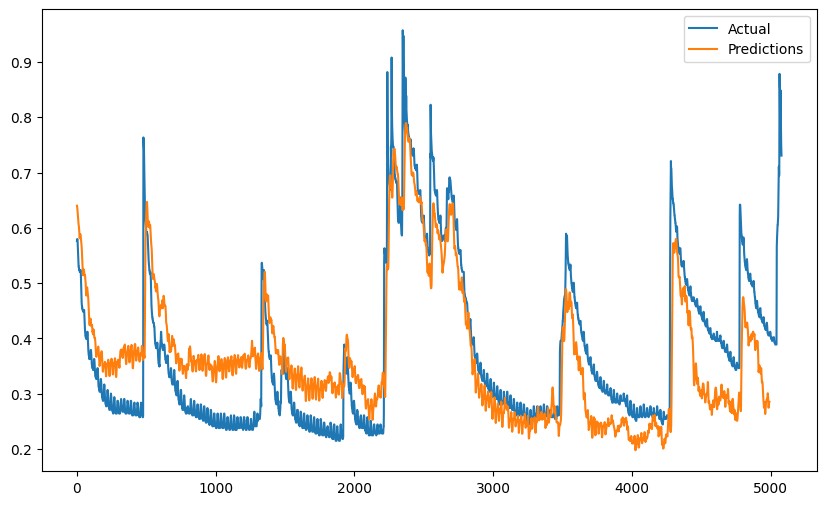

In [37]:
plot_single_pred(bi_lstm_model,'BiLSTM', test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

In [46]:
ckpt = tf.keras.callbacks.ModelCheckpoint("LSTM" + ".keras", save_best_only=True) # add the .keras extension to the filepath


LSTM_history = compile_and_fit(lstm_model, train_dataset, train_steps, val_dataset, val_steps, batch_size=BATCH_SIZE, model_name="LSTM", patience=PAT)
loss_by_epoch["LSTM"] = LSTM_history.history
val_performance["LSTM"] = lstm_model.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["LSTM"] = lstm_model.evaluate


Epoch 1/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - loss: 0.0310 - mean_absolute_error: 0.1317 - mean_absolute_percentage_error: 2557.1003 - mean_squared_error: 0.0310 - val_loss: 0.0194 - val_mean_absolute_error: 0.1179 - val_mean_absolute_percentage_error: 32.1153 - val_mean_squared_error: 0.0194
Epoch 2/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.0087 - mean_absolute_error: 0.0696 - mean_absolute_percentage_error: 2088.4336 - mean_squared_error: 0.0087 - val_loss: 0.0351 - val_mean_absolute_error: 0.1523 - val_mean_absolute_percentage_error: 36.0086 - val_mean_squared_error: 0.0351
Epoch 3/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.0157 - mean_absolute_error: 0.0965 - mean_absolute_percentage_error: 2299.2295 - mean_squared_error: 0.0157 - val_loss: 0.0434 - val_mean_absolute_error: 0.1684 - val_mean_absolute_percentage_error: 42.5212 - val_mean_squared_error: 0.0434
Epoch 4/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.0095 - mean_absolute_error:

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


{'Predictions': array([0.16618389, 0.16601627, 0.16542356, ..., 0.5316061 , 0.5352322 ,
        0.5383699 ], dtype=float32),
 'Actual': array([0.57619943, 0.57948471, 0.57948471, ..., 0.74703377, 0.73717794,
        0.73060739])}

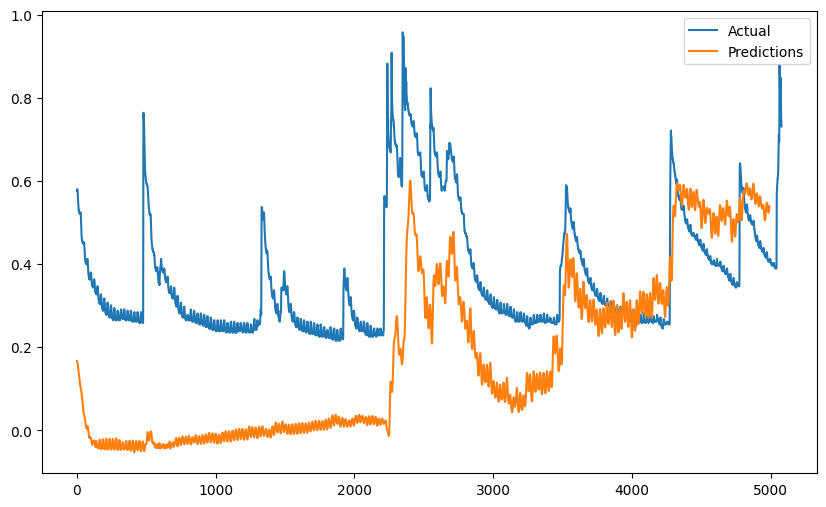

In [47]:
plot_single_pred(lstm_model,'LSTM', test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

In [50]:
!pip install keras-self-attention


  Preparing metadata (setup.py) ... done
  Created wheel for keras-self-attention: filename=keras_self_attention-0.51.0-py3-none-any.whl size=18894 sha256=d2b73a7e5f40ef4f1ec9a4b8dc423796da15cda16e15de83eab772400925ff5c
  Stored in directory: /root/.cache/pip/wheels/b8/f7/24/607b483144fb9c47b4ba2c5fba6b68e54aeee2d5bf6c05302e
Successfully built keras-self-attention


In [67]:
# Compile the model
lstm_model_with_attention.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                                  loss='mse',
                                  metrics=['mae', 'mse'])

ckpt = tf.keras.callbacks.ModelCheckpoint("lstmWithSelfAttention" + ".keras", save_best_only=True)

# Train the model using the compile_and_fit function
lstm_with_attention_history = compile_and_fit(lstm_model_with_attention, train_dataset, train_steps, val_dataset, val_steps,
                                              batch_size=BATCH_SIZE, model_name="lstmWithSelfAttention", patience=PAT)
loss_by_epoch["lstmWithSelfAttention"] = lstm_with_attention_history.history

val_performance["lstmWithSelfAttention"] = lstm_model_with_attention.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["lstmWithSelfAttention"] = lstm_model_with_attention.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)


Epoch 1/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 24s 73ms/step - loss: 0.0419 - mean_absolute_error: 0.1561 - mean_absolute_percentage_error: 2416.3779 - mean_squared_error: 0.0419 - val_loss: 0.0235 - val_mean_absolute_error: 0.1347 - val_mean_absolute_percentage_error: 35.6663 - val_mean_squared_error: 0.0235
Epoch 2/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - loss: 0.0182 - mean_absolute_error: 0.1078 - mean_absolute_percentage_error: 1869.6409 - mean_squared_error: 0.0182 - val_loss: 0.0271 - val_mean_absolute_error: 0.1434 - val_mean_absolute_percentage_error: 38.8092 - val_mean_squared_error: 0.0271
Epoch 3/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - loss: 0.0182 - mean_absolute_error: 0.1084 - mean_absolute_percentage_error: 2101.7190 - mean_squared_error: 0.0182 - val_loss: 0.0202 - val_mean_absolute_error: 0.1240 - val_mean_absolute_percentage_error: 31.8790 - val_mean_squared_error: 0.0202
Epoch 4/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 0.0158 - mean_absolute_err

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
asd


{'Predictions': array([0.6608176 , 0.66052234, 0.6601894 , ..., 0.45022452, 0.44994664,
        0.44963938], dtype=float32),
 'Actual': array([0.57619943, 0.57948471, 0.57948471, ..., 0.74703377, 0.73717794,
        0.73060739])}

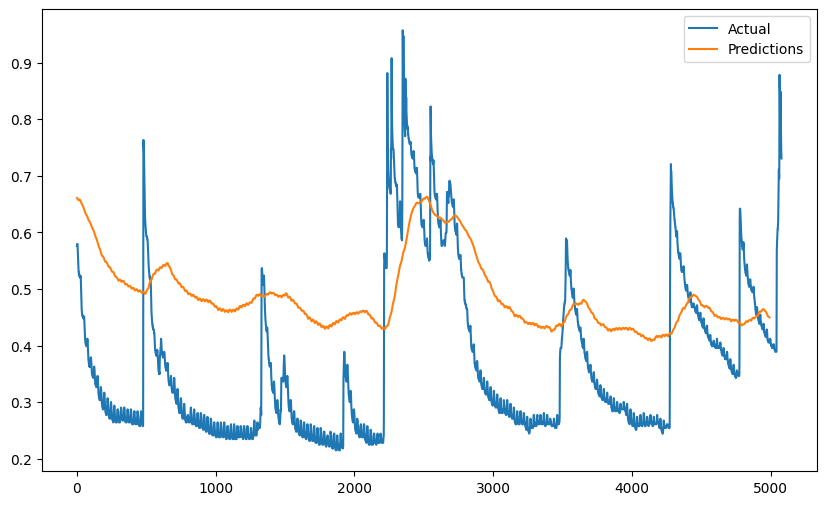

In [68]:
plot_single_pred(lstm_model_with_attention,'LSTM with Attention', test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

In [69]:
ckpt = tf.keras.callbacks.ModelCheckpoint("biLSTMWithSelfAttention" + ".keras", save_best_only=True) # add the .keras extension to the filepath

bi_lstm_model_with_attention_history = compile_and_fit(bi_lstm_model_with_attention, train_dataset, train_steps, val_dataset, val_steps, batch_size=BATCH_SIZE, model_name="biLSTMWithSelfAttention", patience=PAT)
loss_by_epoch["biLSTMWithSelfAttention"] = bi_lstm_model_with_attention_history.history
val_performance["biLSTMWithSelfAttention"] = bi_lstm_model_with_attention.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["biLSTMWithSelfAttention"] = bi_lstm_model_with_attention.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)


Epoch 1/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 40s 120ms/step - loss: 0.0454 - mean_absolute_error: 0.1596 - mean_absolute_percentage_error: 2387.3420 - mean_squared_error: 0.0454 - val_loss: 0.0408 - val_mean_absolute_error: 0.1712 - val_mean_absolute_percentage_error: 49.1243 - val_mean_squared_error: 0.0408
Epoch 2/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 33s 115ms/step - loss: 0.0204 - mean_absolute_error: 0.1138 - mean_absolute_percentage_error: 1632.2924 - mean_squared_error: 0.0204 - val_loss: 0.0254 - val_mean_absolute_error: 0.1391 - val_mean_absolute_percentage_error: 36.9983 - val_mean_squared_error: 0.0254
Epoch 3/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 31s 109ms/step - loss: 0.0191 - mean_absolute_error: 0.1093 - mean_absolute_percentage_error: 2199.2781 - mean_squared_error: 0.0191 - val_loss: 0.0301 - val_mean_absolute_error: 0.1484 - val_mean_absolute_percentage_error: 41.5081 - val_mean_squared_error: 0.0301
Epoch 4/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 32s 112ms/step - loss: 0.0186 - mean_absolute

39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
asd


{'Predictions': array([-0.02199335, -0.02209875, -0.02222494, ...,  0.06571133,
         0.06555255,  0.06534673], dtype=float32),
 'Actual': array([0.57619943, 0.57948471, 0.57948471, ..., 0.74703377, 0.73717794,
        0.73060739])}

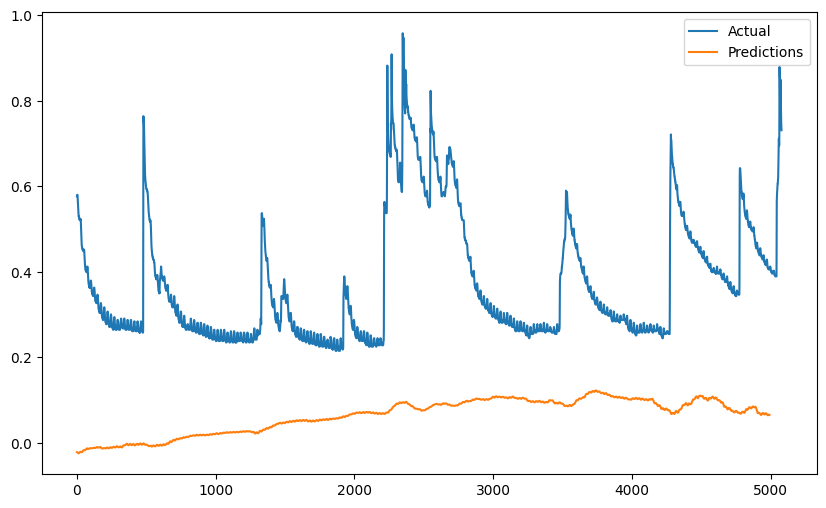

In [71]:
plot_single_pred(bi_lstm_model_with_attention,'BiLSTM with Attention', test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

In [73]:
# trying again with differenet activation functions for the attention layer (sigmoid now)
from keras_self_attention import SeqSelfAttention


lstm_model_with_attention = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(32, return_sequences=True),  # Set return_sequences=True for attention
    SeqSelfAttention(attention_activation='sigmoid'),  # Add attention layer
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh')
])

#biLSTM with an attention layer

bi_lstm_model_with_attention = tf.keras.models.Sequential([
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True)),  # Set return_sequences=True for attention
    SeqSelfAttention(attention_activation='sigmoid'),  # Add attention layer
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh')
])




In [74]:
# Compile the model
lstm_model_with_attention.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                                  loss='mse',
                                  metrics=['mae', 'mse'])

ckpt = tf.keras.callbacks.ModelCheckpoint("lstmWithSelfAttention" + ".keras", save_best_only=True)

# Train the model using the compile_and_fit function
lstm_with_attention_history = compile_and_fit(lstm_model_with_attention, train_dataset, train_steps, val_dataset, val_steps,
                                              batch_size=BATCH_SIZE, model_name="lstmWithSelfAttention", patience=PAT)
loss_by_epoch["lstmWithSelfAttention"] = lstm_with_attention_history.history

val_performance["lstmWithSelfAttention"] = lstm_model_with_attention.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["lstmWithSelfAttention"] = lstm_model_with_attention.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)


Epoch 1/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - loss: 0.0442 - mean_absolute_error: 0.1695 - mean_absolute_percentage_error: 2678.9111 - mean_squared_error: 0.0442 - val_loss: 0.0269 - val_mean_absolute_error: 0.1427 - val_mean_absolute_percentage_error: 38.8754 - val_mean_squared_error: 0.0269
Epoch 2/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 0.0200 - mean_absolute_error: 0.1159 - mean_absolute_percentage_error: 2715.0679 - mean_squared_error: 0.0200 - val_loss: 0.0259 - val_mean_absolute_error: 0.1404 - val_mean_absolute_percentage_error: 37.9528 - val_mean_squared_error: 0.0259
Epoch 3/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 0.0197 - mean_absolute_error: 0.1158 - mean_absolute_percentage_error: 2726.5906 - mean_squared_error: 0.0197 - val_loss: 0.0233 - val_mean_absolute_error: 0.1334 - val_mean_absolute_percentage_error: 35.6800 - val_mean_squared_error: 0.0233
Epoch 4/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - loss: 0.0181 - mean_absolute_err

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
asd


{'Predictions': array([0.54098094, 0.54016423, 0.53927594, ..., 0.42776462, 0.42667812,
        0.4255996 ], dtype=float32),
 'Actual': array([0.57619943, 0.57948471, 0.57948471, ..., 0.74703377, 0.73717794,
        0.73060739])}

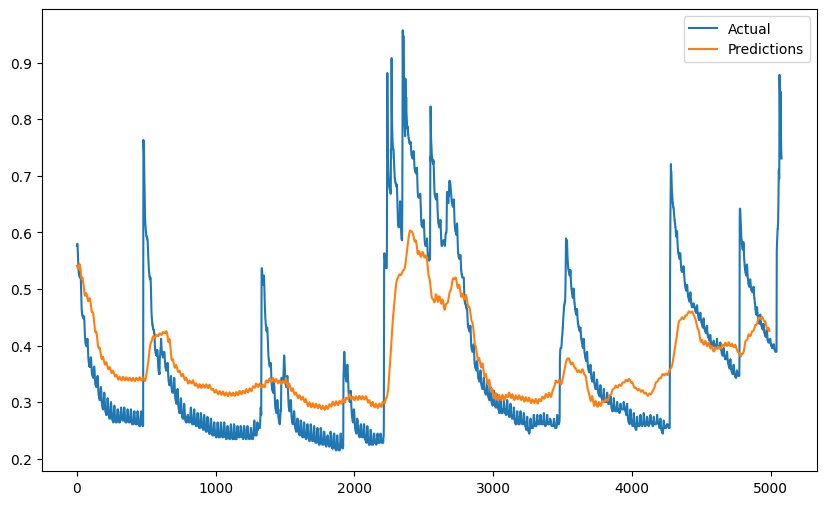

In [75]:
plot_single_pred(lstm_model_with_attention,'LSTM with Attention', test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

In [76]:
ckpt = tf.keras.callbacks.ModelCheckpoint("biLSTMWithSelfAttention" + ".keras", save_best_only=True) # add the .keras extension to the filepath

bi_lstm_model_with_attention_history = compile_and_fit(bi_lstm_model_with_attention, train_dataset, train_steps, val_dataset, val_steps, batch_size=BATCH_SIZE, model_name="biLSTMWithSelfAttention", patience=PAT)
loss_by_epoch["biLSTMWithSelfAttention"] = bi_lstm_model_with_attention_history.history
val_performance["biLSTMWithSelfAttention"] = bi_lstm_model_with_attention.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["biLSTMWithSelfAttention"] = bi_lstm_model_with_attention.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)


Epoch 1/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 39s 110ms/step - loss: 0.0640 - mean_absolute_error: 0.1877 - mean_absolute_percentage_error: 2350.0620 - mean_squared_error: 0.0640 - val_loss: 0.0305 - val_mean_absolute_error: 0.1510 - val_mean_absolute_percentage_error: 42.0183 - val_mean_squared_error: 0.0305
Epoch 2/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 31s 108ms/step - loss: 0.0212 - mean_absolute_error: 0.1165 - mean_absolute_percentage_error: 2101.1445 - mean_squared_error: 0.0212 - val_loss: 0.0163 - val_mean_absolute_error: 0.0973 - val_mean_absolute_percentage_error: 20.2235 - val_mean_squared_error: 0.0163
Epoch 3/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 31s 107ms/step - loss: 0.0148 - mean_absolute_error: 0.0943 - mean_absolute_percentage_error: 2667.7568 - mean_squared_error: 0.0148 - val_loss: 0.0251 - val_mean_absolute_error: 0.1382 - val_mean_absolute_percentage_error: 37.4475 - val_mean_squared_error: 0.0251
Epoch 4/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 31s 107ms/step - loss: 0.0136 - mean_absolute

39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step
asd


{'Predictions': array([0.69153976, 0.6915518 , 0.69156307, ..., 0.47559646, 0.4755881 ,
        0.47559118], dtype=float32),
 'Actual': array([0.57619943, 0.57948471, 0.57948471, ..., 0.74703377, 0.73717794,
        0.73060739])}

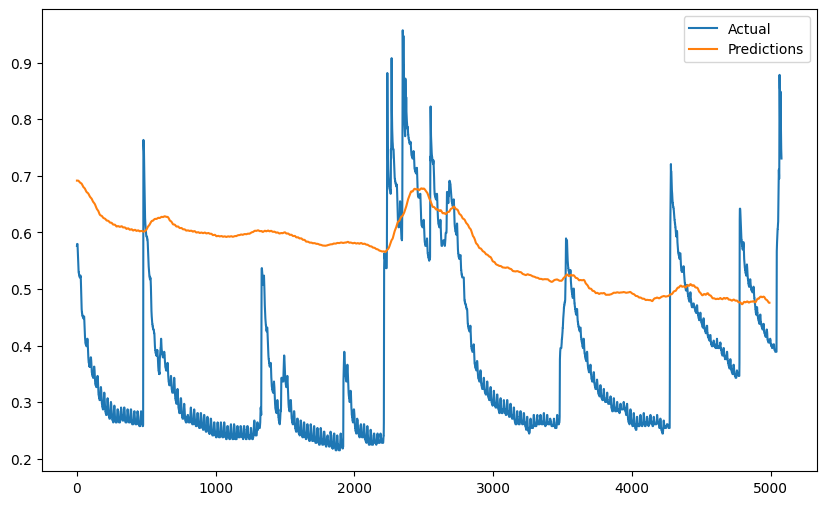

In [77]:
plot_single_pred(bi_lstm_model_with_attention,'BiLSTM with Attention', test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

In [ ]:
# which model performed best